# Student Depression Severity Project

Author: Munna R. Shainy [[Find me on LinkedIn]](https://www.linkedin.com/in/munnars)

Year: 2026

An exploratory data analysis and machine learning project investigating whether lifestyle factors can predict self-perceived depression severity in students.

This project uses the Student Depression Dataset available [here (https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset) with 27840 responses (Overall responses: 27,901) from college students across different cities in India.

#### Research Question
Can dietary habits, sleep duration, and genetic predisposition distinguish between students with no depression, depression without suicidal ideation, and depression with suicidal thoughts?

##### ⚠️ Disclaimer
##### This is an academic exercise. The following model building is **exploratory only**. Depression in this dataset is self-perceived (not clinically diagnosed), and suicidal thoughts reflect lifetime history rather than current ideation. The severity classes constructed are approximations, and results should not be interpreted as a clinical tool.


In [99]:
import os
from pathlib import Path

# Anchor: repo root is one level above /notebooks
REPO_ROOT = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd().parent

# ── Define all project paths ──────────────────────────────────────────────────
PATHS = {
    "data_raw":       REPO_ROOT / "data" / "raw",
    "images":         REPO_ROOT / "images",
}

# ── Auto-create folders if they don't exist ───────────────────────────────────
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"✔ {name:16} → {path}")

✔ data_raw         → /Users/3happi/Desktop/data/raw
✔ images           → /Users/3happi/Desktop/images


In [100]:
import numpy as np
import pandas as pd

import warnings

pd.options.mode.chained_assignment = None  # suppresses SettingWithCopyWarning
warnings.filterwarnings('ignore')           # suppresses all other warnings

### Data Exploration and Basic Visualizations

In [101]:
df=pd.read_csv("data/student_depression_dataset.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


In [102]:
df.columns = df.columns.str.replace(' ', '_') #adding underscores to spaces in colnames
df.columns = df.columns.str.replace('/', 'OR') #adding underscores to spaces in colnames
df.columns = df.columns.str.replace('Have_you_ever_had_suicidal_thoughts_?', 'Suicidal_Thoughts') #renaming a long colname
print(df.columns)
#What are the different categories/responses available in the data
print(df['City'].unique())
print(df['Profession'].unique())
print(df['Sleep_Duration'].unique())
print(df['Dietary_Habits'].unique())
print(df['Degree'].unique())
print(df['Gender'].unique())


#Descriptive statistics
df.describe()

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic_Pressure',
       'Work_Pressure', 'CGPA', 'Study_Satisfaction', 'Job_Satisfaction',
       'Sleep_Duration', 'Dietary_Habits', 'Degree', 'Suicidal_Thoughts',
       'WorkORStudy_Hours', 'Financial_Stress',
       'Family_History_of_Mental_Illness', 'Depression'],
      dtype='object')
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City'
 '3.0' "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad']
['Student' "'Civil Engineer'" 'Architect' "'UX/UI Designer'"
 "'Digital Marketer'" "'Content Writer'" "'Educational Consultant'"
 'Tea

,id,Age,Academic_Pressure,Work_Pressure,CGPA,Study_Satisfaction,Job_Satisfaction,WorkORStudy_Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [103]:
students = df[(df['Profession'] == 'Student') & (df['Sleep_Duration'] != 'Others') & (df['Dietary_Habits'] != 'Others') & (df['Profession'] != 'Class 12')]
students.columns = students.columns.str.replace('WorkORStudy_Hours', 'Study_Hours') #renaming a colname
students.columns = students.columns.str.replace('Family_History_of_Mental_Illness','Genetic_Predisposition')  #renaming a colname
students.describe()

,id,Age,Academic_Pressure,Work_Pressure,CGPA,Study_Satisfaction,Job_Satisfaction,Study_Hours,Depression
count,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000
mean,70446.750359,25.819899,3.140625,0.000431,7.656119,2.943247,0.000682,7.159303,0.585165
std,40638.435883,4.906639,1.381793,0.044040,1.470790,1.361100,0.044443,3.706734,0.492702
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35064.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70673.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105827.250000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


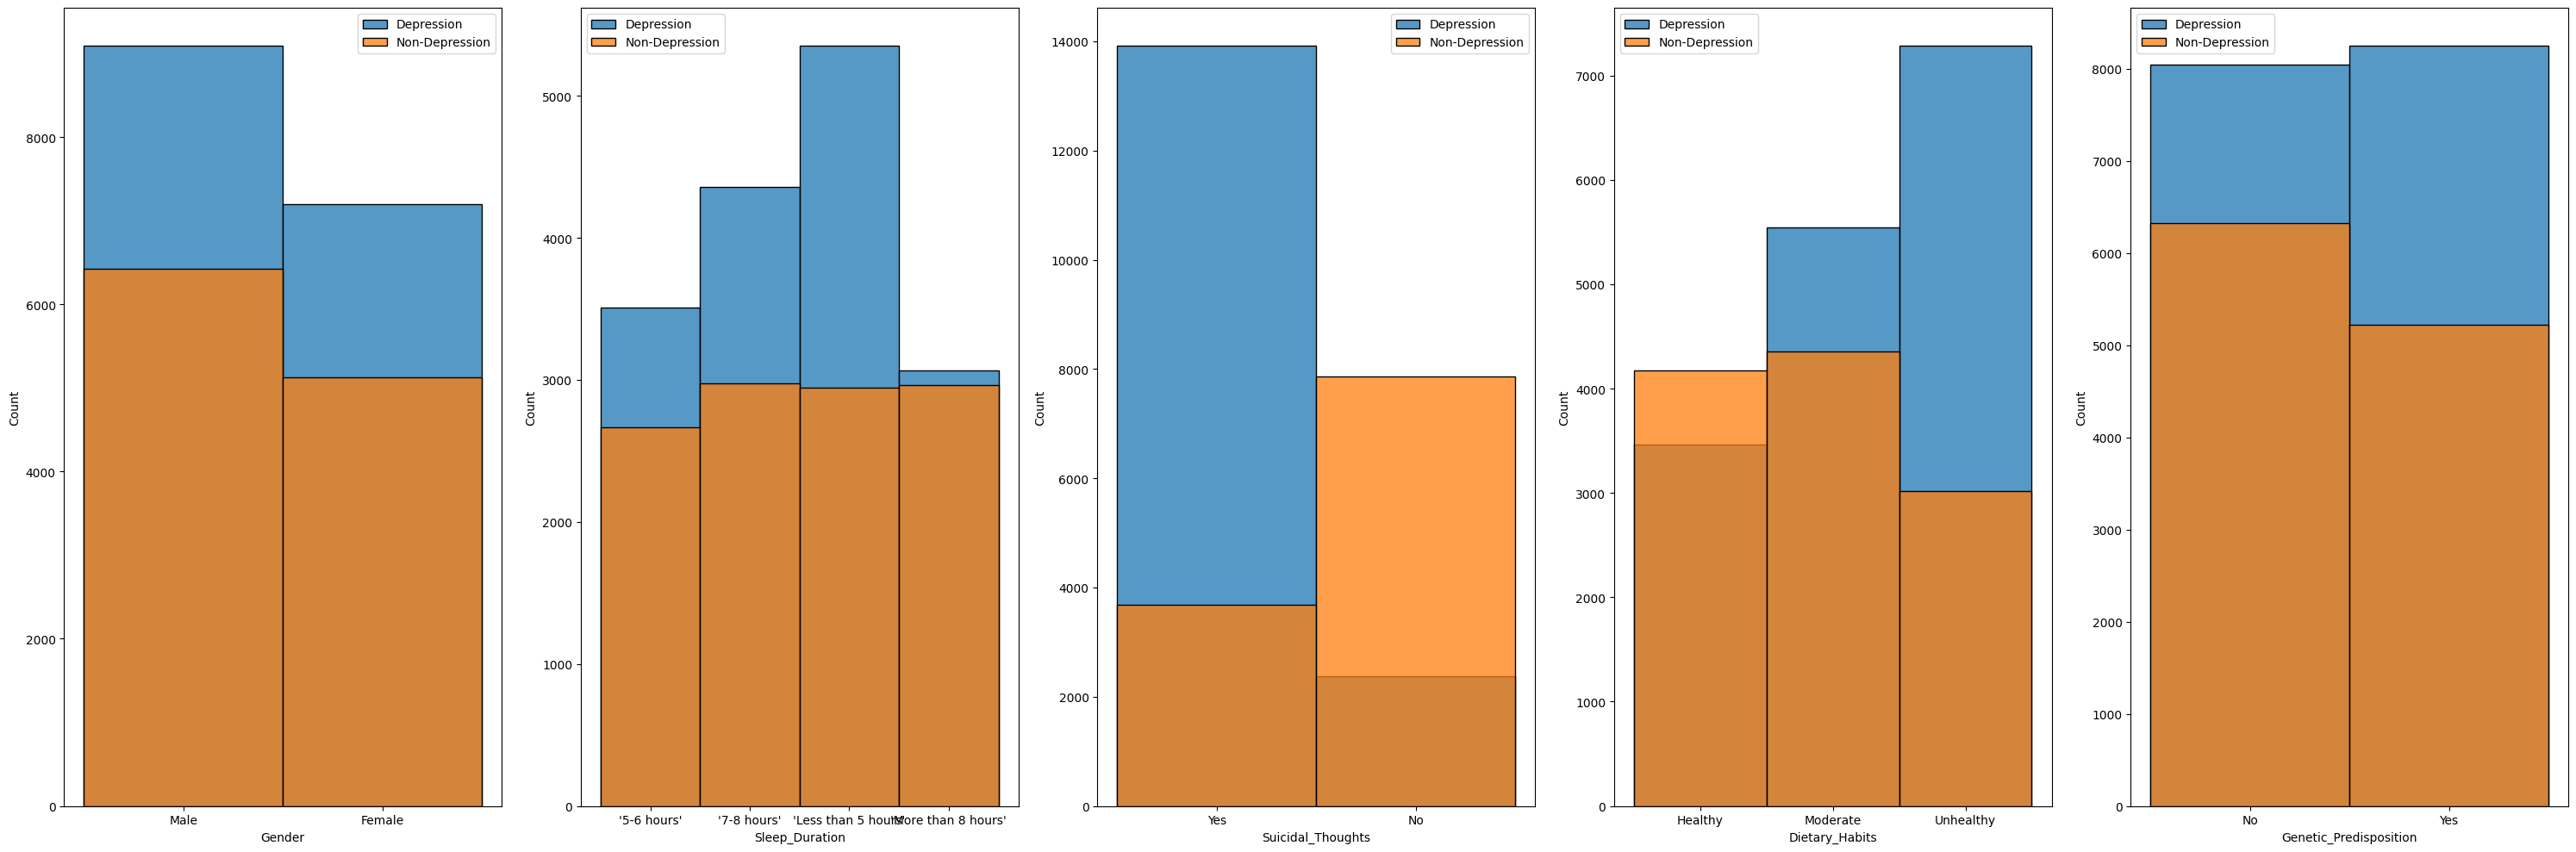

In [104]:
#Plotting Depression v/s Non-Depression across Categorical Variables

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(ncols=5,nrows=1,figsize=(30, 10))

#Plot for Students by Gender
ax = sns.histplot(students[students['Depression']==1].Gender.dropna(), label = 'Depression', ax = axes[0])
ax = sns.histplot(students[students['Depression']==0].Gender.dropna(), label = 'Non-Depression', ax = axes[0])
ax.legend()

#Plot for Students by Sleep_Duration
ax = sns.histplot(students[students['Depression']==1].Sleep_Duration.dropna(), label = 'Depression', ax = axes[1])
ax = sns.histplot(students[students['Depression']==0].Sleep_Duration.dropna(),label = 'Non-Depression', ax = axes[1])
ax.legend()

#Plot for Students by Suicidal_Thoughts
ax = sns.histplot(students[students['Depression']==1].Suicidal_Thoughts.dropna(), label = 'Depression', ax = axes[2])
ax = sns.histplot(students[students['Depression']==0].Suicidal_Thoughts.dropna(), label = 'Non-Depression', ax = axes[2])
ax.legend()

#Plot for Students by Dietary_Habits
ax = sns.histplot(students[students['Depression']==1].Dietary_Habits.dropna(), label = 'Depression', ax = axes[3])
ax = sns.histplot(students[students['Depression']==0].Dietary_Habits.dropna(), label = 'Non-Depression', ax = axes[3])
ax.legend()

#Plot for Students by Family History
ax = sns.histplot(students[students['Depression']==1].Genetic_Predisposition.dropna(), label = 'Depression', ax = axes[4])
ax = sns.histplot(students[students['Depression']==0].Genetic_Predisposition.dropna(), label = 'Non-Depression', ax = axes[4])
ax.legend()

plt.tight_layout()
plt.savefig(PATHS["images"] / "01_categorical_vars_depression.png", dpi=150, bbox_inches="tight")
plt.show()

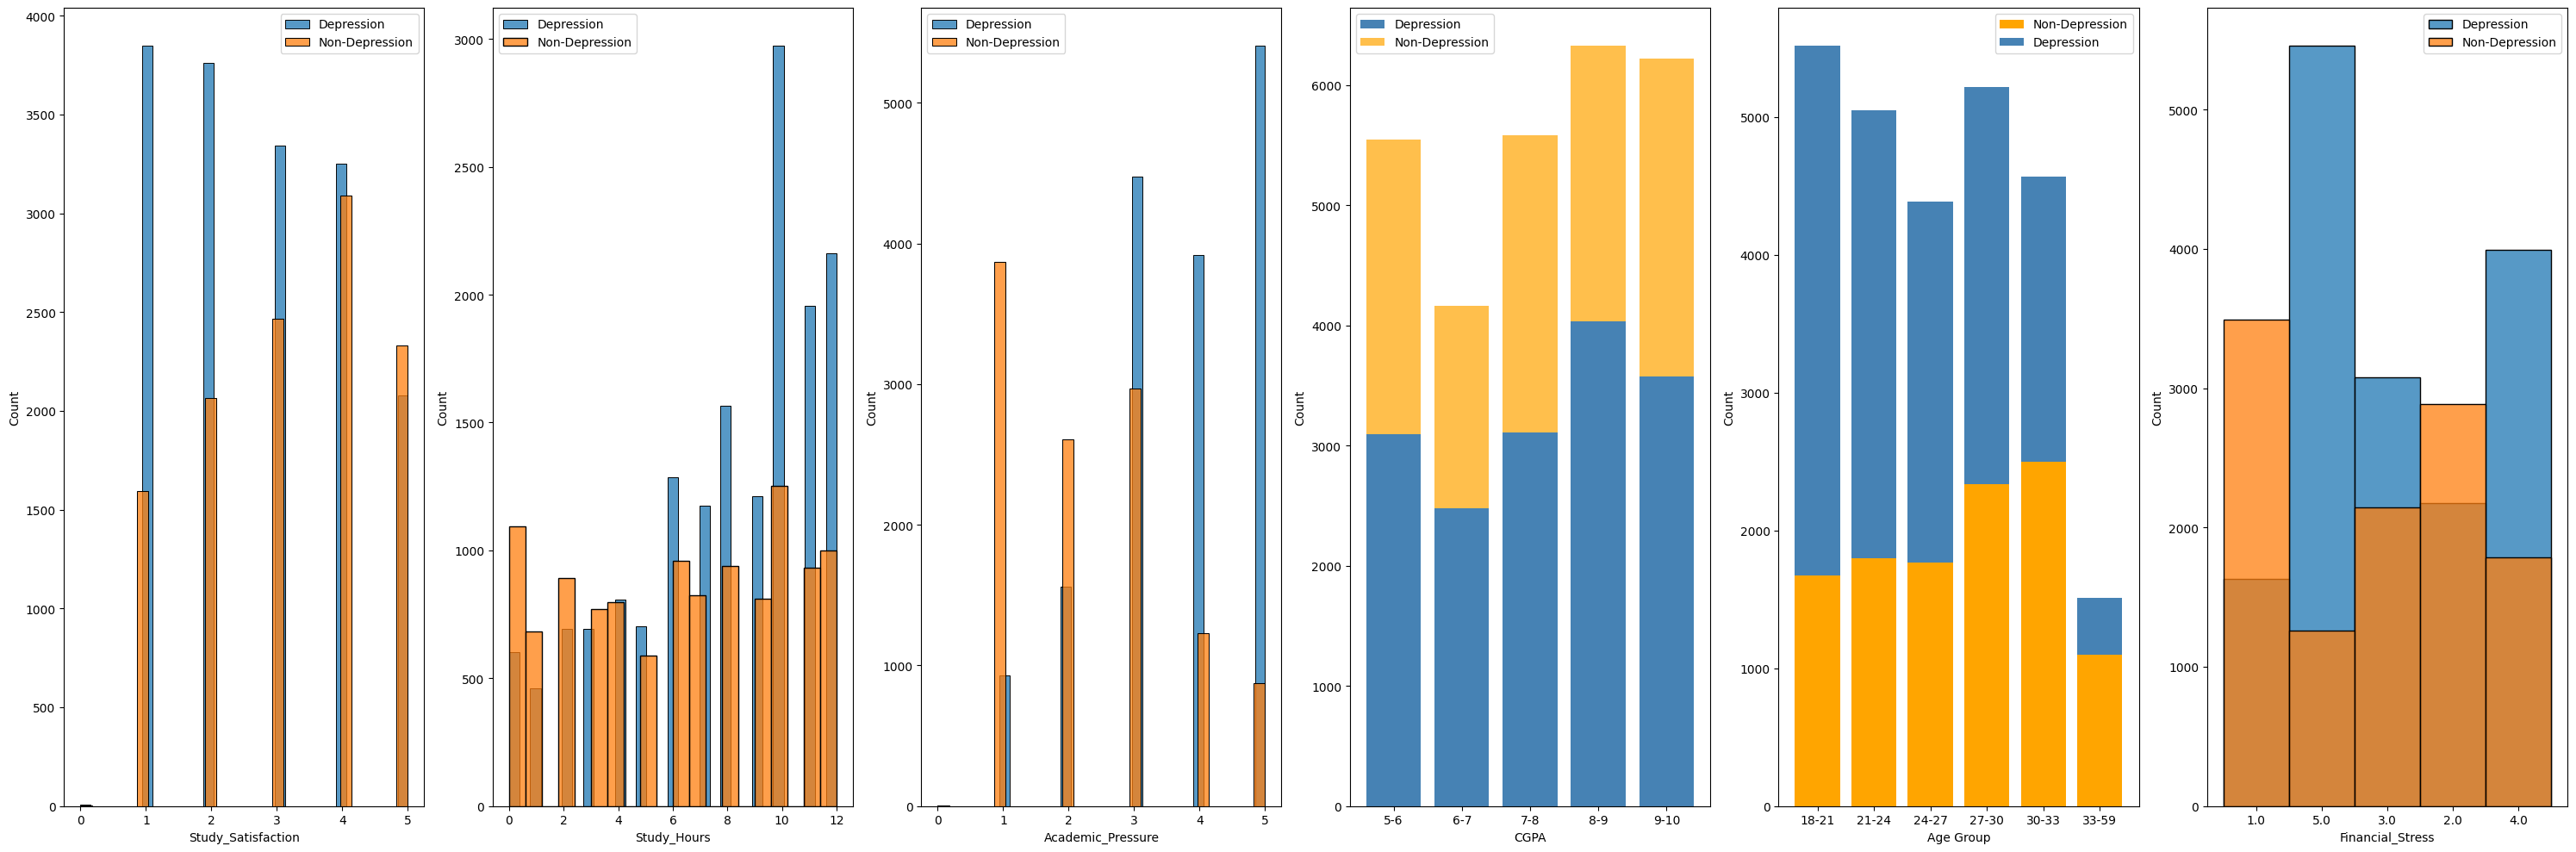

In [105]:
#Plotting Depression v/s Non-Depression across Continuous Variables

fig, axes = plt.subplots(ncols=6,nrows=1,figsize=(30, 10))

#Plot for Students by Study_Satisfaction
ax = sns.histplot(students[students['Depression']==1].Study_Satisfaction.dropna(), label = 'Depression', ax = axes[0])
ax = sns.histplot(students[students['Depression']==0].Study_Satisfaction.dropna(), label = 'Non-Depression', ax = axes[0])
ax.legend()

#Plot for Students by Study_Hours
ax = sns.histplot(students[students['Depression']==1].Study_Hours.dropna(), label = 'Depression', ax = axes[1])
ax = sns.histplot(students[students['Depression']==0].Study_Hours.dropna(), label = 'Non-Depression', ax = axes[1])
ax.legend()

#Plot for Students by Academic Pressure
ax = sns.histplot(students[students['Depression']==1].Academic_Pressure.dropna(), label = 'Depression', ax = axes[2])
ax = sns.histplot(students[students['Depression']==0].Academic_Pressure.dropna(), label = 'Non-Depression', ax = axes[2])
ax.legend()

#Plot for Students by CGPA
## Requires binning CGPA
students['CGPA'] = pd.cut(students['CGPA'], bins=[5,6,7,8,9,10], 
                               labels=['5-6','6-7','7-8','8-9','9-10'])

dep    = students[students['Depression']==1]['CGPA'].value_counts().sort_index()
non_dep = students[students['Depression']==0]['CGPA'].value_counts().sort_index()

axes[3].bar(dep.index, dep.values, label='Depression', color='steelblue')
axes[3].bar(non_dep.index, non_dep.values, bottom=dep.values, label='Non-Depression', color='orange', alpha=0.7)
axes[3].set_xlabel('CGPA')
axes[3].set_ylabel('Count')
axes[3].legend()

#Plot for Students by Age
## Requires binning Age
students['Age'] = pd.cut(students['Age'], bins=[18,21,24,27,30,33,59],
                              labels=['18-21','21-24','24-27','27-30','30-33','33-59'])
dep     = students[students['Depression']==1]['Age'].value_counts().sort_index()
non_dep = students[students['Depression']==0]['Age'].value_counts().sort_index()
axes[4].bar(non_dep.index, non_dep.values, label='Non-Depression', color='orange')
axes[4].bar(dep.index, dep.values, bottom=non_dep.values, label='Depression', color='steelblue')
axes[4].set_xlabel('Age Group')
axes[4].set_ylabel('Count')
axes[4].legend()

#Plot for Students by Financial_Stress
students = df[df['Financial_Stress'] != '?'] #omitting unknown financial_stress data points

ax = sns.histplot(students[students['Depression']==1]['Financial_Stress'].dropna(),
                  label='Depression', ax=axes[5], discrete=True)
ax = sns.histplot(students[students['Depression']==0]['Financial_Stress'].dropna(),
                  label='Non-Depression', ax=axes[5], discrete=True)
ax.legend()

plt.tight_layout()
plt.savefig(PATHS["images"] / "02_continuous_vars_depression.png", dpi=150, bbox_inches="tight")
plt.show()

### Research Question ?
#### Can lifestyle and biological factors, specifically dietary habits, sleep duration, and genetic predisposition, predict the severity of depression in students, distinguishing between no depression, depression without suicidal ideation (SI),  and depression with suicidal ideation?

In [106]:
# Is there comorbidity of self-reported depression & suicidal thoughts, in this dataset?

from scipy.stats import chi2_contingency
import numpy as np

students['Financial_Stress'] = students['Financial_Stress'].astype(float)
students['Gender'] = students['Gender'].astype(object)

# 2.2 — Drop irrelevant columns
students = students.drop(columns=[
    'id',
    'City',                                    # too many categories, low signal
    'Profession',                              # all students; not needed
    'Work_Pressure',                           # not relevant for students
    'Job_Satisfaction',                        # not relevant for students
    'Degree',                                   # too many categories, low signal
    'Gender'
    
])

# Contingency table
contingency = pd.crosstab(students['Depression'], 
                          students['Suicidal_Thoughts'])
print("Contingency Table:\n", contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Cramér's V (effect size)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nChi-square statistic : {chi2:.2f}")
print(f"P-value              : {p:.2e}")
print(f"Degrees of freedom   : {dof}")
print(f"Cramér's V           : {cramers_v:.3f}")

Contingency Table:
 Suicidal_Thoughts    No    Yes
Depression                    
0                  7864   3699
1                  2378  13957

Chi-square statistic : 8323.37
P-value              : 0.00e+00
Degrees of freedom   : 1
Cramér's V           : 0.546


### Comorbidity:

- Depressed students who also have suicidal thoughts: 13,957,  by far the largest group
- Non-depressed students with suicidal thoughts: 3,699, notable, worth flagging as a limitation (suicidal thoughts exist outside depression too) 
- Depressed without suicidal thoughts: only 2,378 — Class 1 will be the smallest class, so expecting the model to struggle most here

In this data, depression and suicidal thoughts are strongly and significantly associated (χ² = 8323, p ≈ 0, V = 0.546), statistically justifying their combination into a severity-based target variable.

In [107]:
#Create a new Multiclass Target that encapsulates both the presence of depression and suicidal ideations

def assign_class(row):
    if row['Depression'] == 0:
        return 0  # Not depressed
    elif row['Suicidal_Thoughts'] == 'No':
        return 1  # Depressed, no suicidal thoughts
    else:
        return 2  # Depressed, with suicidal thoughts

students['Depression_Severity'] = students.apply(assign_class, axis=1)

print(students['Depression_Severity'].value_counts().sort_index())
print("\nAs percentages:")
print(students['Depression_Severity'].value_counts(normalize=True).sort_index().mul(100).round(1))

### Depression with no suicidal thoughts is only 8.5% available in the dataset

Depression_Severity
0    11563
1     2378
2    13957
Name: count, dtype: int64

As percentages:
Depression_Severity
0    41.4
1     8.5
2    50.0
Name: proportion, dtype: float64


In [108]:
# Rename the column
students.columns = students.columns.str.replace('Family_History_of_Mental_Illness','Genetic_Predisposition')

# Convert Yes/No to 1/0
students['Genetic_Predisposition'] = students['Genetic_Predisposition'].map({
    'Yes': 1,
    'No': 0
})

features = ['Sleep_Duration', 'Dietary_Habits', 'Genetic_Predisposition'] #specifying lifestyle features

X = students[features].copy()
y = students['Depression_Severity']

from sklearn.preprocessing import LabelEncoder

# Encode the 3 categorical columns
le = LabelEncoder()
for col in features:
    X[col] = le.fit_transform(X[col].astype(str))

from sklearn.model_selection import train_test_split

# Re-split with new X
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features used:", X.columns.tolist())
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Features used: ['Sleep_Duration', 'Dietary_Habits', 'Genetic_Predisposition']
Train size: (22318, 3)
Test size:  (5580, 3)


── Logistic Regression ──────────────────────────────
                      precision    recall  f1-score   support

       No Depression       0.50      0.66      0.57      2313
  Depression (no SI)       0.10      0.43      0.16       476
Depression (with SI)       0.51      0.09      0.15      2791

            accuracy                           0.35      5580
           macro avg       0.37      0.39      0.29      5580
        weighted avg       0.47      0.35      0.32      5580



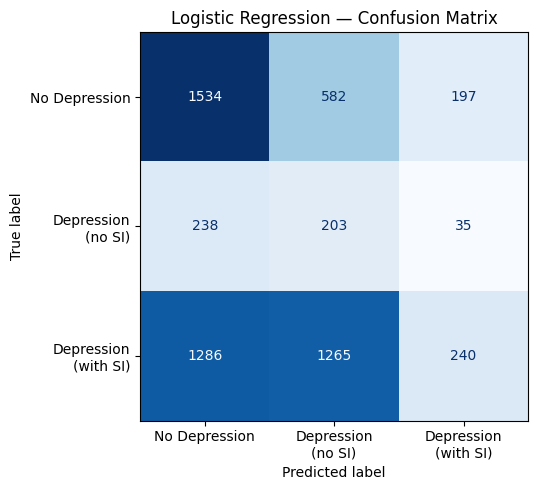

In [109]:
# Baseline Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("── Logistic Regression ──────────────────────────────")
print(classification_report(y_test, y_pred_lr, 
      target_names=['No Depression', 'Depression (no SI)', 'Depression (with SI)']))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, 
      display_labels=['No Depression', 'Depression\n(no SI)', 'Depression\n(with SI)'],
      ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig(PATHS["images"] / "03_lr_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

                      precision    recall  f1-score   support

       No Depression       0.52      0.60      0.56      2313
  Depression (no SI)       0.09      0.28      0.13       476
Depression (with SI)       0.56      0.27      0.37      2791

            accuracy                           0.41      5580
           macro avg       0.39      0.39      0.35      5580
        weighted avg       0.50      0.41      0.43      5580



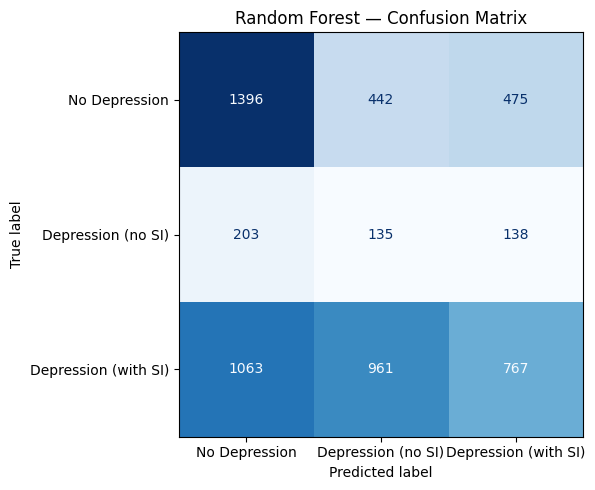

In [110]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf,
      target_names=['No Depression', 'Depression (no SI)', 'Depression (with SI)']))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
      display_labels=['No Depression', 'Depression (no SI)', 'Depression (with SI)'],
      ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig(PATHS["images"] / "04_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

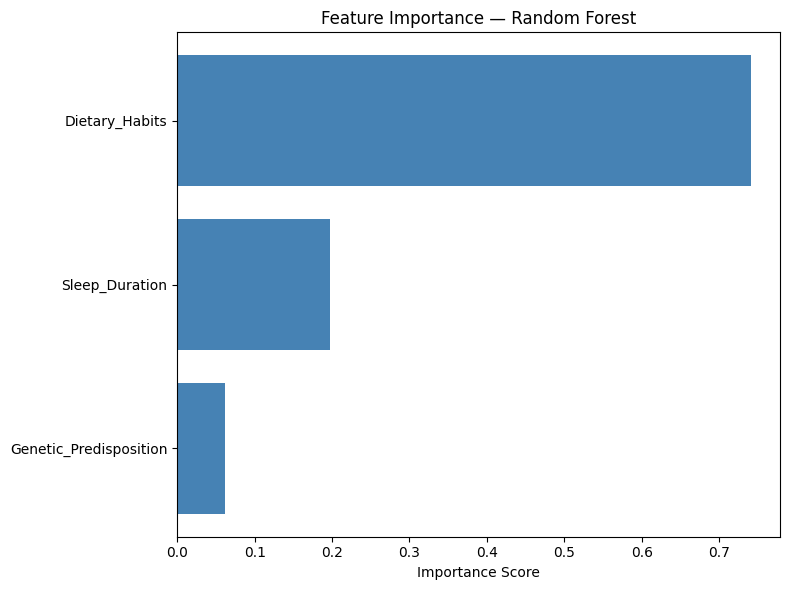

In [111]:
#Feature Importance (Random Forest) 

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig(PATHS["images"] / "05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation
##### Logistic Regression
- Completely failed to predict Class 2 (Depression with SI) — every single one of those 2,791 cases was predicted as 0
- Can only draw straight lines — these 3 features don't separate the classes linearly at all

##### Random Forest
- Slightly better overall (41% vs 35%)
- At least attempts all 3 classes unlike LR
- Still badly struggles with Class 1 (Depression, no SI) — only 28% recall, meaning it misses 72% of those cases

Class 1 (Depression, no SI) — both models fail here
- F1 of 0.16 and 0.13 respectively
- This is your key finding — 3 lifestyle features simply cannot distinguish "depressed without suicidal ideation" from the other groups

## Conclusion

---

### Key Findings

**1. Strong comorbidity between depression and suicidal ideation**
A chi-square test confirmed a statistically significant association between depression 
and suicidal thoughts (χ² = 8323, p ≈ 0, Cramér's V = 0.546), justifying the 
construction of a severity-based target variable.

**2. Lifestyle factors alone are insufficient predictors of depressive severity**
Both models performed poorly overall (LR: 35%, RF: 41% accuracy), and critically, 
neither could reliably identify students with depression but no suicidal ideation 
(F1 < 0.16 across both models).

**3. Dietary habits is the strongest lifestyle predictor**
Among the three features, dietary habits contributed approx. 74% of the predictive signal 
in the Random Forest model, followed by sleep duration (approx. 20%) and genetic 
predisposition (approx. 6%).

**4. Suicidal ideation cannot be inferred from lifestyle alone**
The consistent failure to classify Class 1 (Depression, no SI) and Class 2 
(Depression, with SI) apart suggests these groups are not meaningfully separable 
using only the three features tested.

---

### ⚠️ Critical Dataset Limitation

This dataset relies on **self-perceived depression** (not clinical diagnosis) and 
**lifetime history of suicidal thoughts** (not current ideation). As a result:

- The severity classes constructed in this analysis are approximations, not 
  clinically validated categories
- A student reporting past suicidal thoughts may not currently be at risk, 
  inflating Class 2 artificially
- Model performance should be interpreted in this context — the target variable 
  itself carries significant noise

This further reinforces the conclusion that **self-reported lifestyle surveys 
are insufficient for clinical depression screening**, and that proper diagnosis 
requires validated clinical instruments administered by professionals.

### Limitations
- Only 3 features were used by design — broader lifestyle features may improve performance
- Class imbalance (Class 1 = 8.5%) likely suppressed model performance on that class
- The dataset is survey-based and self-reported, introducing response bias
- Findings are correlational, not causal

---

### Clinical Implication
Passive lifestyle monitoring is insufficient for detecting suicidal ideation in 
depressed students. Direct, structured clinical screening remains essential and 
cannot be replaced by observable lifestyle signals alone.